# 🐪 Day 8 · Build Your Own College Chatbot with RAG
#### 🎒 Student edition: everything from class, plus ✍️ practice exercises and 🏠 homework
### AI/ML + GenAI + Agentic AI Industry Workshop · SKIT Jaipur × Kvon Tech

**Today's mission:** build **Campus Buddy**, a chatbot that answers questions about a college (or a company) **from its documents**, instead of making things up.

Everything runs **free inside this notebook**: no API keys, no paid services, no sign-ups.

| Roadmap topic | Where we do it |
|---|---|
| Why chatbots make things up | Part 1 |
| **Embeddings** | Part 2 |
| **Retrieval** (semantic search) | Part 3 |
| **Document processing** | Part 4 |
| **RAG architecture** | Part 5 |
| **Vector databases** | Part 6 |
| 🎯 **College/Company RAG Chatbot** | Parts 7 and 8 |

### How to use this notebook
1. **File → Save a copy in Drive** (now it's yours to edit).
2. **Runtime → Change runtime type → T4 GPU → Save.**
3. Run cells **one by one** with **Shift + Enter**. We'll run them together, so don't jump ahead 🙂
4. ✍️ Practice cells contain `FILL_ME` blanks. **Runtime → Run all** stops at them until you fill them in. To catch up after a disconnect, click the cell you were on and use **Runtime → Run before**.

### Signs you'll see
🧠 new idea · 🔮 predict before you run · ✋ your turn: change something! · 🎮 game · ✅ checkpoint
✍️ practice: try it yourself first, then open the ✅ solution cell below it

---
## Part 0 · Get ready ⏱️ 3 minutes
Run the next **four** cells now. They download two free AI models from Hugging Face (an open website that hosts AI models, like GitHub for AI).

> 💡 If you see a yellow message about **HF_TOKEN**, ignore it. That's the *optional* Hugging Face login. We don't need any key!

In [ ]:
# @title 🔧 0.1 · Install the extra tools (about 1 minute)
!pip install -q "gradio>=6,<7" "chromadb>=1.5,<2" pypdf fpdf2 sentence-transformers
print("✅ Installed: gradio (web apps), chromadb (vector database), pypdf (read PDFs), fpdf2 (make PDFs)")

In [ ]:
# @title 🧠 0.2 · Load our two free AI models (1–2 minutes the first time)
import warnings
warnings.filterwarnings("ignore")              # hide harmless warning messages
import torch
import transformers
from transformers import pipeline
from sentence_transformers import SentenceTransformer, util
transformers.logging.set_verbosity_error()

gpu = torch.cuda.is_available()
print("🖥️ GPU available:", gpu)
if not gpu:
    print("⚠️ No GPU: each answer will take about 10 seconds. For speed: Runtime → Change runtime type → T4 GPU.")

# Model 1: the EMBEDDING model turns any text into 384 numbers (22 million parameters, 90 MB)
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Model 2: the CHAT model reads a message and writes a reply (1.5 billion parameters, 3 GB)
chat_model_name = "Qwen/Qwen2.5-1.5B-Instruct"   # no GPU and too slow? use "Qwen/Qwen2.5-0.5B-Instruct" (faster, more mistakes)
chatbot = pipeline("text-generation", model=chat_model_name,
                   dtype=torch.float16 if gpu else torch.float32,
                   device="cuda" if gpu else "cpu")
print("✅ Loaded the embedding model and the chat model:", chat_model_name)

In [ ]:
# @title 📚 0.3 · Our sample documents: a made-up college, a made-up company and 26 movies { display-mode: "form" }
# The college and the company are MADE UP on purpose: no AI model has ever read about them,
# so if a model "knows" an answer about them, it either read our documents or it invented it.

COLLEGE_HANDBOOK = """Pixelpur Institute of Technology (PIT) - Student Handbook 2026-27
(A made-up college created for the Day 8 RAG workshop.)

About the College
Pixelpur Institute of Technology (PIT) is a private engineering college in Pixelpur, Rajasthan, founded in 1998. It offers B.Tech in Computer Science, AI & Data Science, Electronics, Mechanical and Civil Engineering, and a 3-year BCA programme. The Director is Dr. Meera Kulkarni. The college motto is "Learn, Build, Share".

College Mascot
The college mascot is Chintu, a friendly camel who wears a graduation cap. A statue of Chintu stands near the main gate, and students touch his hump for good luck before exams.

Class Timings
Classes run from 9:00 AM to 4:00 PM, Monday to Friday, with a lunch break from 12:30 PM to 1:15 PM. Saturdays are for labs, club activities and extra classes from 9:00 AM to 1:00 PM. Sunday is a holiday.

Attendance Rules
Every student needs at least 75% attendance in each subject to sit for the end-semester exam. Students with 65% to 74% attendance can appeal to their Head of Department with a valid medical certificate. Attendance is updated every Monday on the PIT student portal.

Examinations
Mid-semester exams are held in the 8th week of each semester. End-semester exams are held in December and May. Reach the exam hall at least 15 minutes early; no one is allowed to enter more than 30 minutes after the exam starts. Mobile phones, smart watches and earbuds are not allowed in the exam hall. Re-evaluation of an answer sheet costs Rs. 500 per subject.

Central Library
The central library is on the 2nd floor of Block B. It is open from 8:00 AM to 8:00 PM on weekdays and from 10:00 AM to 2:00 PM on Saturdays. It is closed on Sundays. During exam weeks it stays open until 11:00 PM. Students can borrow up to 4 books for 14 days. The late fine is Rs. 5 per book per day.

Canteen - Byte Bites
The canteen, called Byte Bites, is next to the basketball court and is open from 8:00 AM to 6:00 PM. The most popular dish is the Debugger Dosa (Rs. 60). Masala chai costs Rs. 10 and a samosa costs Rs. 15. Every Friday is Rajasthani Day, when dal baati churma is served for Rs. 80.

Campus Wi-Fi
The student Wi-Fi network is called PIT-Student. Each student gets 5 GB of data per day. To reset your Wi-Fi password, visit the IT Help Desk in Room A-104 with your college ID card.

Hostels and Mess
Boys stay in Aravalli Hostel and girls stay in Thar Hostel. Hostel in-time: every student must be back inside the hostel by 9:30 PM. Mess timings: breakfast 7:30 to 9:00 AM, lunch 12:30 to 2:00 PM and dinner 7:30 to 9:00 PM. Visitors can meet students in the visitors' room on Sundays from 10:00 AM to 6:00 PM.

Tech Fest - Pixel Mela
The annual tech fest, Pixel Mela, is held from 14 to 16 February. Events include a 24-hour hackathon, a robo-race, a coding contest and an AI poster competition. The hackathon winner gets Rs. 50,000. Registration opens on 1 January.

Clubs
PIT has five student clubs: CodeCamels (coding), RoboRaiders (robotics), Sur Sangam (music), Clickers (photography) and Nautanki (drama). Clubs meet on Saturdays after 11:00 AM.

College Buses
College buses run on 12 routes across the city. The first bus leaves Pixelpur Railway Station at 7:45 AM. A yearly bus pass costs Rs. 18,000. A duplicate bus pass costs Rs. 200 at the Transport Office.

Scholarships
Students with a CGPA of 9.0 or above get a 25% tuition fee waiver for the next year. Students who win a medal at a state-level sports event get a one-time award of Rs. 10,000.

Training and Placements
The Training and Placement Cell is in Room C-201, Block C. Placement training starts in the 5th semester. In 2025-26, 212 students were placed; the highest package was Rs. 24 LPA and the average package was Rs. 6.2 LPA.

ID Cards
Students must wear their ID card on campus at all times. A lost ID card can be replaced at the Admin Office for Rs. 150.

Medical Help
The medical room is Room A-010 on the ground floor of Block A. A nurse is available from 9:00 AM to 5:00 PM. For emergencies, call the campus ambulance on internal extension 108.

Anti-Ragging
Ragging is strictly banned at PIT and is punishable by suspension. Report any incident to the Dean of Students, Prof. Arjun Mehta, in Room A-201, or through the anti-ragging form on the student portal."""

COMPANY_HANDBOOK = """CamelCase Technologies Pvt. Ltd. - Employee Handbook 2026
(A made-up company created for the Day 8 RAG workshop.)

About Us
CamelCase Technologies is a software startup in Pixelpur, Rajasthan, founded in 2019. We build mobile apps and AI chatbots for small businesses and have 85 employees. Our CEO is Ms. Kavya Rathore.

Working Hours
Office hours are 10:00 AM to 6:30 PM, Monday to Friday. Everyone must be available during the core hours of 11:00 AM to 4:00 PM. The office is closed on Saturdays and Sundays.

Work From Home
After finishing probation, employees can work from home 2 days a week, usually Tuesday and Thursday. Interns work from the office all 5 days.

Probation and Notice Period
New employees are on probation for 6 months. The notice period is 15 days during probation and 60 days after confirmation.

Leaves and Holidays
Every employee gets 18 paid leaves and 8 sick leaves per year, plus 10 public holidays. Up to 5 unused paid leaves can be carried forward to the next year. The office is closed for the whole Diwali week.

Salary and Payslips
Salary is credited on the last working day of every month. Payslips are available on the HR portal, CamelDesk.

Internships
Interns get a monthly stipend of Rs. 25,000. The internship lasts 6 months. Interns who perform well can receive a pre-placement offer (PPO).

Laptops and IT
Every employee gets a company laptop on the first day. A lost or stolen laptop must be reported to the IT team within 24 hours.

Learning Budget
Each employee has a learning budget of Rs. 20,000 per year for online courses, books and conferences.

Food and Fun
Lunch is free for everyone on Fridays, and tea and coffee are free all day. The office dog, Bug, visits every Wednesday.

Referral Bonus
If you refer a friend and they stay with the company for 90 days, you get a referral bonus of Rs. 50,000.

Expense Claims
Submit bills for travel and other work expenses on CamelDesk within 30 days.

Dress Code
The dress code is smart casual. Wear formal clothes on client meeting days.

Respect at Work
Harassment of any kind is not tolerated. Complaints can be raised with the HR team or the Internal Complaints Committee (ICC)."""

MOVIES = {
    '3 Idiots': 'Three friends at a top engineering college question an education system that cares only about marks. Rancho believes in learning for understanding, not for grades.',
    'Dangal': 'A former wrestler from Haryana trains his two daughters in the sport, breaking village traditions, until one of them wins a gold medal for India at the Commonwealth Games.',
    'Lagaan': 'In 1893, poor villagers who cannot pay a heavy tax accept a challenge from a British officer: if they win a cricket match, the tax will be cancelled.',
    'Sholay': 'A retired police officer hires two small-time crooks, Jai and Veeru, to capture the cruel bandit Gabbar Singh, who terrorises the village of Ramgarh.',
    'Taare Zameen Par': 'An eight-year-old boy who struggles with reading and writing is sent to a boarding school, where an art teacher discovers that he has dyslexia and helps him shine.',
    'PK': 'An alien lands in Rajasthan, loses the remote control of his spaceship, and asks innocent questions about religion and blind faith.',
    'Chak De! India': "A former hockey captain, blamed for a loss, coaches the Indian women's hockey team and turns a group of quarrelling players into world champions.",
    'Baahubali': 'In the ancient kingdom of Mahishmati, a young man discovers his royal family and fights a cruel king to free his mother. Everyone wants to know why Kattappa killed Baahubali.',
    'RRR': 'In the 1920s, two Indian revolutionaries, one a police officer and one a tribal protector, become best friends while fighting British rule. Their song Naatu Naatu won an Oscar.',
    '12th Fail': 'Based on a true story, a poor boy from Chambal who failed class 12 studies day and night in Delhi to crack the UPSC exam and become an IPS officer.',
    'Munna Bhai M.B.B.S.': "A kind-hearted Mumbai gangster joins a medical college to fulfil his father's dream and teaches everyone the power of a warm hug, the jaadu ki jhappi.",
    'Zindagi Na Milegi Dobara': 'Three childhood friends go on a road trip across Spain before one of them gets married, and together they face their fears through skydiving, deep-sea diving and the running of the bulls.',
    'Queen': 'A shy girl from Delhi is dumped by her fiance a day before the wedding, so she goes alone on her honeymoon to Paris and Amsterdam and discovers her confidence.',
    'Andhadhun': 'A pianist who pretends to be blind accidentally witnesses a murder and gets trapped in a chain of dark and funny twists.',
    'Drishyam': 'A cable TV operator who loves watching films uses clever tricks to protect his family from the police after they accidentally cause a death.',
    'Swades': 'A NASA scientist returns to a village in India and helps the villagers build a small hydroelectric plant to get electricity.',
    'Dilwale Dulhania Le Jayenge': "Two young Indians fall in love on a trip across Europe, and the hero wins over the girl's strict father instead of running away with her.",
    'Titanic': 'A poor artist and a rich young woman fall in love aboard a luxury liner that hits an iceberg and goes down in the Atlantic Ocean in 1912.',
    'Interstellar': 'When crops on Earth are dying, a team of astronauts flies through a wormhole near Saturn to find a new planet where people can live.',
    'Finding Nemo': "A nervous clownfish crosses the ocean to find his son, who was caught by a diver and put in a dentist's fish tank.",
    'Jurassic Park': 'Scientists bring dinosaurs back to life from ancient DNA for an island theme park, but the dinosaurs escape.',
    'The Lion King': 'A lion cub prince runs away after his uncle kills his father, then returns as an adult to take back his kingdom.',
    "Harry Potter and the Philosopher's Stone": 'An orphan boy learns on his eleventh birthday that he is a wizard and goes to a school of magic, where he makes friends and faces a dark wizard.',
    'Avengers: Endgame': 'Superheroes travel back in time to collect the Infinity Stones and undo the snap that wiped out half of all life.',
    'Inception': "A thief who steals secrets by entering people's dreams is given one last job: to plant an idea deep inside someone's mind.",
    'Toy Story': 'Toys come alive when humans are not looking. A cowboy doll becomes jealous when a new space-ranger toy arrives.',
}

print(f"📘 College handbook: {len(COLLEGE_HANDBOOK.split())} words")
print(f"📗 Company handbook: {len(COMPANY_HANDBOOK.split())} words")
print(f"🎬 Movie stories: {len(MOVIES)}")

In [ ]:
# @title 🎨 0.4 · Display helpers: just run it (open it later if you're curious) { display-mode: "form" }
import html
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import HTML, display
from sklearn.decomposition import PCA

BOX = ("font-family:system-ui,'Segoe UI',Roboto,sans-serif;border-radius:12px;padding:12px 16px;"
       "margin:8px 0;color:#1f2937;line-height:1.55;font-size:15px")


def esc(text):
    return html.escape(str(text))


def bot_card(question, answer, label="🤖 Campus Buddy", color="#dbeafe"):
    display(HTML(f'<div style="{BOX};background:#f3f4f6"><b>🧑‍🎓 You:</b> {esc(question)}'
                 f'<div style="background:{color};border-radius:10px;padding:8px 12px;margin-top:8px">'
                 f'<b>{label}:</b> {esc(answer)}</div></div>'))


def score_bar(score, width=220):
    pct = max(0.0, min(1.0, score)) * 100
    color = "#16a34a" if score >= 0.6 else "#f59e0b" if score >= 0.35 else "#ef4444"
    return (f'<span style="display:inline-block;width:{width}px;background:#e5e7eb;border-radius:6px;'
            f'vertical-align:middle"><span style="display:block;width:{pct:.0f}%;background:{color};'
            f'height:14px;border-radius:6px"></span></span> <b>{score:.2f}</b>')


def show_similarity(sentence_1, sentence_2, score):
    display(HTML(f'<div style="{BOX};background:#f9fafb">1️⃣ {esc(sentence_1)}<br>2️⃣ {esc(sentence_2)}'
                 f'<div style="margin-top:8px"><b>Similarity:</b> {score_bar(score, 300)}</div></div>'))


def show_ranking(title, items, medals=True):
    rows = "".join(f'<tr><td style="padding:4px 10px 4px 0">{"🥇🥈🥉"[n] if medals and n < 3 else ""}</td>'
                   f'<td style="padding:4px 14px 4px 0">{esc(label)}</td><td>{score_bar(score)}</td></tr>'
                   for n, (label, score) in enumerate(items))
    display(HTML(f'<div style="{BOX};background:#f9fafb"><b>{esc(title)}</b><table>{rows}</table></div>'))


def show_results(found):
    display(HTML("".join(
        f'<div style="{BOX};background:#fefce8;border-left:6px solid #eab308"><b>#{n}</b> · '
        f'{score_bar(c["score"], 160)} · <i>{esc(c["source"])}</i><br>{esc(c["text"])}</div>'
        for n, c in enumerate(found, start=1))))


def show_prompt(prompt):
    display(HTML(f'<div style="{BOX};background:#111827;color:#e5e7eb"><b>📨 The exact message the chat model '
                 f'will read:</b><pre style="white-space:pre-wrap;font-size:13px;margin:8px 0 0;color:#e5e7eb">'
                 f'{esc(prompt)}</pre></div>'))


def show_table(rows, columns, html_cells=False):
    head = "".join(f'<th style="text-align:left;padding:8px 10px;background:#e0e7ff">{esc(c)}</th>' for c in columns)
    body = "".join("<tr>" + "".join(f'<td style="padding:8px 10px;border-top:1px solid #e5e7eb;vertical-align:top">'
                                    f'{cell if html_cells else esc(cell)}</td>' for cell in row) + "</tr>" for row in rows)
    display(HTML(f'<div style="{BOX};background:#ffffff;padding:0;overflow-x:auto">'
                 f'<table style="border-collapse:collapse;width:100%"><tr>{head}</tr>{body}</table></div>'))


def mark(text, is_correct):
    return ("✅ " if is_correct else "❌ ") + str(text)


def show_movies(movies):
    show_table([[f"<b>{esc(title)}</b>", esc(story)] for title, story in movies.items()], ["🎬 Movie", "Story"],
               html_cells=True)


def show_chroma(result):
    found = [{"text": t, "source": m["source"], "score": 1 - d}
             for t, m, d in zip(result["documents"][0], result["metadatas"][0], result["distances"][0])]
    show_results(found)


CHUNK_COLORS = ["#fde68a", "#bfdbfe", "#bbf7d0", "#fbcfe8", "#ddd6fe", "#fed7aa"]


def show_chunks(chunks, overlap=0, max_show=8):
    cards = []
    for n, chunk in enumerate(chunks[:max_show]):
        words = [esc(w) for w in chunk.split()]
        if n > 0:
            words = [f'<u style="text-decoration-color:#dc2626;text-decoration-thickness:3px">{w}</u>'
                     if i < overlap else w for i, w in enumerate(words)]
        cards.append(f'<div style="{BOX};background:{CHUNK_COLORS[n % len(CHUNK_COLORS)]}"><b>Chunk {n + 1}</b> '
                     f'({len(chunk.split())} words)<br>{" ".join(words)}</div>')
    more = f"<p>… and {len(chunks) - max_show} more chunks.</p>" if len(chunks) > max_show else ""
    display(HTML(f"<p><b>{len(chunks)} chunks in total.</b> Red underline = words repeated from the previous "
                 f"chunk (the overlap).</p>" + "".join(cards) + more))


def show_barcodes(sentences, how_many=64):
    vectors = embedder.encode(sentences)[:, :how_many]
    fig = px.imshow(vectors, y=sentences, aspect="auto", color_continuous_scale="RdBu", zmin=-0.15, zmax=0.15,
                    title=f"🧬 Each row is one sentence: the first {how_many} of its 384 numbers as colours")
    fig.update_layout(height=140 + 60 * len(sentences), template="plotly_white",
                      xaxis_title="position in the list of numbers", yaxis_title=None)
    fig.show()


def meaning_map(groups, my_words=""):
    words = [w for ws in groups.values() for w in ws]
    labels = [g for g, ws in groups.items() for _ in ws]
    extra = [w.strip() for w in my_words.split(",") if w.strip()]
    vectors = embedder.encode(words + extra)
    xy = PCA(n_components=2).fit(vectors[:len(words)]).transform(vectors)   # 384 numbers → 2 numbers (x, y)
    df = pd.DataFrame({"x": xy[:, 0], "y": xy[:, 1], "word": words + extra,
                       "group": labels + ["⭐ your words"] * len(extra)})
    symbols = {g: "circle" for g in groups} | {"⭐ your words": "star"}
    fig = px.scatter(df, x="x", y="y", text="word", color="group", symbol="group", symbol_map=symbols,
                     title="🗺️ The Meaning Map: similar meaning → close together")
    fig.update_traces(textposition="top center", marker_size=14)
    fig.update_layout(height=560, xaxis_visible=False, yaxis_visible=False, template="plotly_white")
    fig.show()


def similarity_heatmap(sentences):
    vectors = embedder.encode(sentences)
    scores = util.cos_sim(vectors, vectors).numpy()
    fig = px.imshow(scores, x=sentences, y=sentences, text_auto=".2f", zmin=0, zmax=1,
                    color_continuous_scale="Blues", title="🔥 How similar is every sentence to every other?")
    fig.update_layout(height=650, template="plotly_white")
    fig.update_xaxes(tickangle=35)
    fig.show()


print("✅ Display helpers ready")

---
## Part 1 · Why do chatbots make things up? 🤥

Meet **Pixelpur Institute of Technology (PIT)**, a *made-up* college. Its principal wants a help-desk chatbot so students stop asking the same questions at the office window.

Let's first try an ordinary chatbot, like the ones you already use.

🧠 **Think of a large language model (LLM) as a student who read lakhs of books, then sits a *closed-book* exam.** It writes from memory.

First, one small function to talk to our chat model.

In [ ]:
def ask_llm(message, system="You are a helpful assistant."):
    """Send one message to the chat model and return its reply as text."""
    conversation = [
        {"role": "system", "content": system},   # hidden instruction: WHO the bot is
        {"role": "user", "content": message},    # what the user typed
    ]
    reply = chatbot(conversation, max_new_tokens=150, do_sample=False)  # do_sample=False → same answer every time
    # reply[0] = the result, ["generated_text"] = the whole chat, [-1] = the bot's new message, ["content"] = its text
    return reply[0]["generated_text"][-1]["content"]


print(ask_llm("Say hello to the students of SKIT Jaipur in one short, fun sentence."))

### 🔮 Step 1: Ask it plainly about PIT
**Predict:** will it know the name of PIT's mascot?

In [ ]:
for question in ["What is the name of the mascot of Pixelpur Institute of Technology?",
                 "What time does the Pixelpur Institute of Technology library close on weekdays?"]:
    bot_card(question, ask_llm(question), label="🤖 Plain chatbot")

It says it doesn't know. Honest, but **useless** as a help desk 😅

### 🔮 Step 2: Give it the job of PIT's help-desk bot
A **system prompt** is a hidden instruction that tells the bot *who it is*. Real company chatbots always have one. Let's give ours the job.

In [ ]:
COLLEGE_SYSTEM = ("You are Campus Buddy, the friendly help-desk chatbot of Pixelpur Institute of Technology (PIT). "
                  "Answer students' questions in one or two short sentences.")

test_questions = ["What is the name of our college mascot?",
                  "What time does the library close on weekdays?",
                  "What is the most popular dish in the canteen?",
                  "Who is the director of the college?"]

closed_book = {}   # we remember the answers so we can check them in the next cell
for question in test_questions:
    closed_book[question] = ask_llm(question, system=COLLEGE_SYSTEM)
    bot_card(question, closed_book[question])

### ✋ Hands up: who believes these answers?
Now let's open PIT's real handbook and check.

In [ ]:
# @title 🔍 1.4 · Reveal the truth from the real handbook { display-mode: "form" }
truth = {"What is the name of our college mascot?": "Chintu, a friendly camel who wears a graduation cap 🐪",
         "What time does the library close on weekdays?": "8:00 PM (11:00 PM during exam weeks)",
         "What is the most popular dish in the canteen?": "The Debugger Dosa (Rs. 60)",
         "Who is the director of the college?": "Dr. Meera Kulkarni"}
show_table([[esc(q), esc(closed_book[q]), f"<b>{esc(truth[q])}</b>"] for q in test_questions],
           ["Question", "🤖 Bot said (closed book)", "📘 Handbook says"], html_cells=True)

### 🧠 What just happened? **Hallucination**
The bot **invented** answers and said them **confidently**. That's called a **hallucination**.

**Why does it happen?** Remember Day 7: an LLM is a *next-word predictor*.
- It has **never read** PIT's handbook (the college doesn't even exist!).
- Its job is to write the most *likely-sounding* next words, so it writes a believable answer.
- Once we told it "you are the help desk", it tried hard to be helpful… by guessing.

It's like a student who doesn't know the answer but fills the page anyway to get marks 😄

**This happens in real life too:** in 2024 a court made Air Canada honour a refund policy that its website chatbot had *invented*.

### 💡 The fix: turn the closed-book exam into an **open-book** exam
Give the bot the right page from the handbook and ask again.

In [ ]:
page = """College Mascot
The college mascot is Chintu, a friendly camel who wears a graduation cap.
A statue of Chintu stands near the main gate."""

message = f"""Use this information to answer.

{page}

Question: What is the name of our college mascot?"""

bot_card("What is the name of our college mascot?", ask_llm(message, system=COLLEGE_SYSTEM))

🎉 **Correct!** Same model, same question. The only difference: we gave it the right page.

But a real college has **hundreds of pages**. Who finds the *right* page for each question, automatically, in less than a second?

That's exactly what **RAG** does:

| Letter | Means | Exam analogy |
|---|---|---|
| **R** | **Retrieval**: find the right pages | Open the textbook at the right chapter |
| **A** | **Augmented**: add them to the question | Keep that page next to the question paper |
| **G** | **Generation**: the LLM writes the answer | Write the answer in your own words |

To find pages by **meaning** (not just matching words), we first need **embeddings** → Part 2.

In [ ]:
# @title ✋ 1.6 · Your turn: ask the closed-book bot anything about PIT (then tell your neighbour what it invented!)
your_question = "How much does a samosa cost in the canteen?"  # @param {type:"string"}
bot_card(your_question, ask_llm(your_question, system=COLLEGE_SYSTEM))

### ✍️ Practice 1 · Make a bot for YOUR college (3 min)
Give the bot a job at SKIT (library, hostel, canteen, exam cell…) in the first box, then ask it something it cannot know. Does it invent an answer? Tell your neighbour what it made up!

In [ ]:
# @title ✍️ Practice 1 · Your own help-desk bot
my_system = "You are the friendly help-desk chatbot of the SKIT Jaipur library. Answer students' questions in one or two short sentences."  # @param {type:"string"}
my_question = "What time does the library close on Saturdays?"  # @param {type:"string"}
bot_card(my_question, ask_llm(my_question, system=my_system), label="🤖 My bot")

✅ **Checkpoint:** An LLM alone is a **closed-book** exam: fluent, but it may invent facts. **RAG = open-book exam.**

---
## Part 2 · Embeddings: turning meaning into numbers 🔢

Computers only understand **numbers**. So how can a computer know that *"My phone is dead"* and *"My mobile has no charge"* mean the same thing?

🧠 **An embedding is a list of numbers that captures the meaning of a text.** Think of it as **GPS coordinates for meaning**:
- Texts with **similar meaning** get **similar numbers**, so they sit **close together** on the "meaning map".
- Our embedding model gives every text **384 numbers**, whether it's one word or a whole paragraph.

Let's look at one.

In [ ]:
vector = embedder.encode("I love samosas")
print("How many numbers in one embedding?", len(vector))
print("The first 10 numbers:", vector[:10].round(3))

Nobody can read meaning from these numbers directly. But we can **draw** them: each number becomes a coloured cell (blue = positive, red = negative), like a barcode. We show the first 64 of the 384 numbers.

🔮 **Predict:** which two barcodes will look alike?

In [ ]:
show_barcodes(["I love samosas", "Samosas are my favourite snack", "The train is late"])

Rows 1 and 2 share many colours, because they mean nearly the same thing. Row 3 is different.

### 🗺️ The Meaning Map
384 numbers are impossible to draw, so we **squash them down to 2 numbers** (x and y), like the shadow of a 3D object on a wall. Some detail is lost, but neighbours stay neighbours.

✋ **Your turn:** type your own words in the box (separated by commas). Where do they land?

In [ ]:
# @title 🗺️ 2.3 · The Meaning Map { run: "auto" }
my_words = "papaya, scooter, tennis, joyful"  # @param {type:"string"}

word_groups = {
    "🍎 fruits": ["apple", "mango", "banana", "grapes"],
    "🚗 vehicles": ["car", "bus", "train", "bicycle"],
    "🏏 sports": ["cricket", "football", "hockey", "badminton"],
    "🐪 animals": ["dog", "cat", "camel", "elephant"],
    "😀 feelings": ["happy", "sad", "angry", "excited"],
}
meaning_map(word_groups, my_words)

### 📏 Measuring "how close": cosine similarity
Think of every embedding as an **arrow**. We compare the **direction** of two arrows:

```
same direction      →→   score ≈ 1    (same meaning)
at a right angle    →↑   score ≈ 0    (unrelated)
```

That score is called **cosine similarity**. Our models almost always give scores between 0 and 1.

In [ ]:
# @title 📏 2.4 · How similar are two sentences? (change them!)
sentence_1 = "My phone's battery is dead."  # @param {type:"string"}
sentence_2 = "My mobile has no charge left."  # @param {type:"string"}

score = util.cos_sim(embedder.encode(sentence_1), embedder.encode(sentence_2)).item()
show_similarity(sentence_1, sentence_2, score)

### 🎮 Game: Guess the Score!
For each pair, **show your guess with your fingers**: 0 fingers = unrelated … 10 fingers = same meaning. Closest guess wins!

In [ ]:
game_pairs = [
    ("I love eating samosas.", "Samosas are my favourite snack."),
    ("My phone's battery is dead.", "My mobile has no charge left."),
    ("I deposited money in the bank.", "We sat on the bank of the river."),
    ("Virat Kohli scored a century.", "The batsman made 100 runs."),
    ("The exam is tomorrow and I have not studied.", "The cat is sleeping on the sofa."),
    ("The movie was boring.", "The movie was not boring."),
]
for n, (a, b) in enumerate(game_pairs, start=1):
    print(f"Pair {n}:  {a}   ↔   {b}")
print("\n✋ Guess each score from 0 to 10 with your fingers!")

In [ ]:
# @title 🎯 2.6 · Reveal the real scores
results = []
for n, (a, b) in enumerate(game_pairs, start=1):
    score = util.cos_sim(embedder.encode(a), embedder.encode(b)).item()
    results.append((f"Pair {n}: {a} ↔ {b}", score))
show_ranking("🎯 Real similarity scores", results, medals=False)

### 🧠 Three lessons from the game
1. **Different words, same meaning → high score** (phone/mobile). Meaning beats spelling.
2. **Same word, different meaning → lower score** (money *bank* vs river *bank*). The model reads the context.
3. ⚠️ **Surprise:** *"boring"* vs *"not boring"* scores **very high**! Embeddings capture the **topic** more than small details like "not".
   So embeddings are great for **finding the right page**, and we still need the LLM to **read it carefully**. That's why RAG uses both.

One more picture: every sentence compared with every other sentence. Darker squares = more similar. Can you spot the 4 topic pairs?

In [ ]:
similarity_heatmap(["I ate a samosa", "I ate a pizza",
                    "Kohli hit a century", "Rohit scored a fifty",
                    "The exam is tomorrow", "I must study for my test",
                    "It is raining today", "The weather is cold"])

### ✍️ Practice 2 · Challenge: fool the similarity meter (5 min)
- **Round A:** find two sentences with **no words in common** that still score **above 0.6**.
- **Round B:** find two sentences that **share important words** but score **below 0.4**.

The examples in the boxes are close but don't win yet. Change them! Think about **meaning**, not spelling.

In [ ]:
# @title ✍️ Practice 2 · Fool the similarity meter { run: "auto" }
round_a_1 = "The kids are playing football."  # @param {type:"string"}
round_a_2 = "Children enjoy a soccer match."  # @param {type:"string"}
round_b_1 = "I read the book on the train."  # @param {type:"string"}
round_b_2 = "I will book a train ticket."  # @param {type:"string"}

score_a = util.cos_sim(embedder.encode(round_a_1), embedder.encode(round_a_2)).item()
score_b = util.cos_sim(embedder.encode(round_b_1), embedder.encode(round_b_2)).item()
show_similarity(round_a_1, round_a_2, score_a)
print("Round A:", "🏆 You win!" if score_a > 0.6 else "Not yet: make both sentences MEAN the same, with different words.")
show_similarity(round_b_1, round_b_2, score_b)
print("Round B:", "🏆 You win!" if score_b < 0.4 else "Not yet: keep a shared word, but change the meaning completely.")

In [ ]:
# @title ✅ Solution to Practice 2 (open only after you try!) { display-mode: "form" }

print("Round A example: 'I am very hungry.'  and  'I want to eat something.'   → about 0.70")
print("Round B example: 'Apple released a new phone.'  and  'I ate a red apple.'   → about 0.34")
print("Why? Embeddings compare MEANING. Same meaning with different words scores high;")
print("the same word (apple) with different meanings (company vs fruit) scores low.")

✅ **Checkpoint:** An **embedding** = a list of numbers for meaning. **Cosine similarity** = how close two meanings are (0 → 1).

🌐 *Website time: explore 10,000 words in 3D on the TensorFlow Embedding Projector (your instructor will show you).*

---
## Part 3 · Semantic search: find by meaning, not by keywords 🔍

Two ways to search:
- **Keyword search** (like **Ctrl+F**): finds pages containing *the same words*.
- **Semantic search** (meaning search): finds pages with *the same meaning*, even with different words. It uses embeddings!

🎬 **Story:** your friend describes a movie but can't remember its name. Can the computer guess it? Here are our 26 movies:

In [ ]:
show_movies(MOVIES)

### Search method 1: keyword search (the old way)

In [ ]:
STOP_WORDS = ["a", "an", "the", "and", "of", "to", "in", "on", "for", "with", "his", "her", "their",
              "who", "is", "was", "about", "it"]      # tiny common words we don't search for


def keyword_search(query):
    """Ctrl+F style: the movie whose story contains the most words of the query wins."""
    best_movie, best_count = "😕 nothing found", 0
    for title, story in MOVIES.items():
        count = 0
        for word in query.lower().split():
            if word not in STOP_WORDS and word in story.lower():   # like pressing Ctrl+F for each word
                count += 1
        if count > best_count:
            best_movie, best_count = title, count
    return best_movie


print(keyword_search("cricket match against the British"))

### Search method 2: meaning search (with embeddings)
Turn every story into an embedding **once**. For each question, embed the question and pick the stories with the **highest similarity**.

In [ ]:
movie_titles = list(MOVIES.keys())
movie_vectors = embedder.encode(list(MOVIES.values()))   # 26 stories → 26 embeddings (done once)


def meaning_search(query, top_k=3):
    """Compare the MEANING of the query with every story and return the top_k closest movies."""
    query_vector = embedder.encode(query)
    results = []
    for title, story_vector in zip(movie_titles, movie_vectors):
        score = util.cos_sim(query_vector, story_vector).item()   # 0 = unrelated … 1 = same meaning
        results.append((score, title))
    results.sort(reverse=True)                                    # biggest score first
    return [(title, score) for score, title in results[:top_k]]


show_ranking("🔍 Meaning search: cricket match against the British",
             meaning_search("cricket match against the British"))

### 🥊 The Battle: Keyword vs Meaning
🔮 **Predict:** for each description below, which method will find the right movie?

In [ ]:
battle = {
    "space mission to save humanity": "Interstellar",
    "a sad romance on a sinking ship": "Titanic",
    "wrestling dad and his girls": "Dangal",
    "friends on a holiday abroad": "Zindagi Na Milegi Dobara",
    "a student preparing for civil services": "12th Fail",
    "cricket match against the British to cancel tax": "Lagaan",
}
rows = []
for query, right_answer in battle.items():
    by_keyword = keyword_search(query)
    by_meaning = meaning_search(query, top_k=1)[0][0]      # [0] = the best match, [0] = its title
    rows.append([query,
                 mark(by_keyword, by_keyword == right_answer),
                 mark(by_meaning, by_meaning == right_answer)])
show_table(rows, ["Description", "Keyword search (Ctrl+F)", "Meaning search (embeddings)"])

🤔 **Discuss with your neighbour:** why did keyword search pick **PK** in rows 1 and 2? Read PK's story in the movie table for a clue.

<details><summary>👀 Click to check your answer</summary>

PK's story contains the word <b>spaceship</b>. Ctrl+F-style search matches letters, so it finds <b>space</b> and <b>ship</b> hiding inside it. Meaning search understood the idea every time.

</details>

### 🎮 Game: Movie Guesser
Describe a movie from the list **without using its name or the main words from its story**. Can the AI still guess it? Try to fool it!

In [ ]:
# @title 🎮 3.5 · Movie Guesser { run: "auto" }
describe_a_movie = "a pianist who is only pretending to be blind"  # @param {type:"string"}
show_ranking(f"🎬 AI's guesses for: {describe_a_movie}", meaning_search(describe_a_movie))

### 🧠 You just built a **retriever**: the **R** in RAG
Let's package it neatly so we can reuse it with any documents. A **class** is just a box that keeps things together.
Our box keeps the **texts**, **where each came from**, and their **embeddings**, and has two buttons: **add** and **search**.

Congratulations, that's a (tiny) **vector database**! 🗄️

In [ ]:
def get_score(result):
    return result["score"]


class MiniVectorDB:
    """Our own tiny vector database: it stores texts with their embeddings and finds the closest ones."""

    def __init__(self):
        self.texts = []      # the pieces of text
        self.sources = []    # where each piece came from
        self.vectors = []    # the embedding of each piece

    def add(self, texts, sources):
        """Store texts, where each one came from, and their embeddings."""
        self.texts += texts
        self.sources += sources
        self.vectors += list(embedder.encode(texts))

    def search(self, question, top_k=3):
        """Return the top_k stored texts whose meaning is closest to the question."""
        question_vector = embedder.encode(question)
        results = []
        for text, source, vector in zip(self.texts, self.sources, self.vectors):
            score = util.cos_sim(question_vector, vector).item()
            results.append({"text": text, "source": source, "score": score})
        results.sort(key=get_score, reverse=True)       # biggest score first
        return results[:top_k]


movie_db = MiniVectorDB()
movie_db.add(list(MOVIES.values()), list(MOVIES.keys()))
show_results(movie_db.search("toys that come alive"))

### ✍️ Practice 3 · Add your favourite movie (4 min)
Write a one-line story for a movie that is **not** in our list, then describe it in **different words**. Does meaning search find it?

In [ ]:
# @title ✍️ Practice 3 · Add your favourite movie
my_title = "Bhaag Milkha Bhaag"  # @param {type:"string"}
my_story = "An Indian athlete who lost his family during the Partition becomes a champion runner known as the Flying Sikh."  # @param {type:"string"}
my_description = "a sprinter who runs away from a painful past"  # @param {type:"string"}

practice_db = MiniVectorDB()
practice_db.add(list(MOVIES.values()) + [my_story], list(MOVIES.keys()) + [my_title])
show_results(practice_db.search(my_description))

✅ **Checkpoint:** **Semantic search** = embed the question, compare with every stored embedding, return the top matches. Keyword search matches *words*; semantic search matches *meaning*.

---
## Part 4 · Document processing: from PDF to chunks 📄✂️

A college's knowledge lives in **PDFs** (handbooks, notices, syllabus). Before our retriever can use a PDF, we process it in **4 steps**, just like making revision notes from a thick textbook:

| Step | What we do | Revision-notes analogy |
|---|---|---|
| 1. **Load** | Read the text out of the PDF | Open the textbook |
| 2. **Clean** | Remove extra spaces and line breaks | Ignore page numbers and scribbles |
| 3. **Chunk** | Cut the text into small pieces | Write one topic per flash card |
| 4. **Label** | Remember where each piece came from | Write the page number on each card |

First, let's make PIT's handbook into a real PDF file (normally the college would give it to you).

In [ ]:
# @title 📄 4.1 · Make two sample PDFs: the college and company handbooks { display-mode: "form" }
from fpdf import FPDF


def make_pdf(text, filename):
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()
    title_block, *sections = text.split("\n\n")
    title, subtitle = title_block.split("\n")
    pdf.set_font("Helvetica", "B", 16)
    pdf.multi_cell(0, 9, title, new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("Helvetica", "I", 10)
    pdf.multi_cell(0, 6, subtitle, new_x="LMARGIN", new_y="NEXT")
    pdf.ln(4)
    for section in sections:
        heading, body = section.split("\n", 1)
        pdf.set_font("Helvetica", "B", 13)
        pdf.multi_cell(0, 8, heading, new_x="LMARGIN", new_y="NEXT")
        pdf.set_font("Helvetica", "", 11)
        pdf.multi_cell(0, 6, body, new_x="LMARGIN", new_y="NEXT")
        pdf.ln(3)
    pdf.output(filename)


make_pdf(COLLEGE_HANDBOOK, "PIT_Student_Handbook.pdf")
make_pdf(COMPANY_HANDBOOK, "CamelCase_Employee_Handbook.pdf")
print("✅ Created PIT_Student_Handbook.pdf and CamelCase_Employee_Handbook.pdf")
print("👈 Click the 📁 Files icon on the left to see them. Double-click to open, or download them!")

### Step 1 · Load

In [ ]:
from pypdf import PdfReader

reader = PdfReader("PIT_Student_Handbook.pdf")
pages = [page.extract_text() for page in reader.pages]      # one text string per page
print("📄 Number of pages:", len(pages))
print("----- Page 1, first 500 characters -----")
print(pages[0][:500])

### Step 2 · Clean
PDF text is full of line breaks (`\n`) where the lines ended on paper. Let's join everything into clean sentences.

In [ ]:
def clean_text(text):
    """Replace line breaks and repeated spaces with single spaces."""
    return " ".join(text.split())


print("BEFORE:", repr(pages[0][:160]))
print("AFTER: ", repr(clean_text(pages[0])[:160]))

### Step 3 · Chunk
Why not give the whole book to the LLM?
- 🧠 The LLM can only read a limited amount at once (remember Day 7's "context window").
- 🎯 Small pieces make search **precise**: the question matches *one topic*, not a mixed page.
- 💰 In real apps, sending less text is faster and cheaper.

We cut the text every **40 words**. Each chunk also repeats the last **10 words** of the previous one (**overlap**), so a sentence cut at the edge still appears whole somewhere.

In [ ]:
def make_chunks(text, chunk_size=40, overlap=10):
    """Cut text into pieces of chunk_size words; each piece re-uses the last `overlap` words of the one before."""
    words = text.split()
    chunks = []
    for start in range(0, len(words), chunk_size - overlap):
        chunks.append(" ".join(words[start:start + chunk_size]))
        if start + chunk_size >= len(words):    # we reached the end of the text
            break
    return chunks


first_chunks = make_chunks(clean_text(pages[0]))
print("Page 1 became", len(first_chunks), "chunks. The first two are:\n")
print("Chunk 1:", first_chunks[0], "\n")
print("Chunk 2:", first_chunks[1])

### ✋ Chunk Visualizer
Move the sliders and watch the chunks change. (Websites like **ChunkViz** do the same thing.)

In [ ]:
# @title ✂️ 4.5 · Chunk Visualizer: move the sliders! { run: "auto" }
chunk_size = 40  # @param {type:"slider", min:10, max:150, step:5}
overlap = 10  # @param {type:"slider", min:0, max:50, step:5}

if overlap >= chunk_size:
    print("⚠️ The overlap must be smaller than the chunk size!")
else:
    show_chunks(make_chunks(clean_text(" ".join(pages)), chunk_size, overlap), overlap)

### ✍️ Practice 4 · Predict the number of chunks (3 min)
**Predict first:** with `chunk_size = 100` and `overlap = 20`, how many chunks will the handbook make?
Write your guess in `my_guess`, replace the two `FILL_ME` with **100** and **20**, then run.

💡 *Hint: each new chunk starts 80 words (100 − 20) after the previous one.*

In [ ]:
my_guess = 0                                                   # ✍️ your guess
text = clean_text(" ".join(pages))
my_chunks = make_chunks(text, chunk_size=FILL_ME, overlap=FILL_ME)     # ✍️ replace FILL_ME with 100 and 20
print("Words in the handbook:", len(text.split()))
print("Your guess:", my_guess, "| Real number of chunks:", len(my_chunks))

In [ ]:
# @title ✅ Solution to Practice 4 (open only after you try!) { display-mode: "form" }

text = clean_text(" ".join(pages))
my_chunks = make_chunks(text, chunk_size=100, overlap=20)
print("Words in the handbook:", len(text.split()))
print("Real number of chunks:", len(my_chunks))
print("Why? Each chunk starts 80 words after the previous one, so about 780 words ÷ 80 ≈ 10 chunks.")

### 🧠 How big should a chunk be?

| Chunk size | What goes wrong | Like… |
|---|---|---|
| **Too small** (10 words) | Pieces lose their context: *"…open until 11:00 PM."* Open? What is? | A flash card with half a sentence |
| **Too big** (whole pages) | One chunk mixes many topics, so search gets fuzzy and the LLM reads lots of junk | Carrying the whole textbook into the exam |
| **Just right** | One idea per chunk, with enough context | A good flash card |

There is **no magic number**. Engineers *test* different sizes with real questions. Let's run that experiment!
(Our handbook is small, so big chunks still work here. In a 500-page document, huge chunks make search fuzzy.)

In [ ]:
# @title 🧪 4.6 · Experiment: which chunk size finds the right answer most often? { display-mode: "form" }
test_set = {   # question → a word that MUST appear in the chunk we find
    "What is the name of our college mascot?": "chintu",
    "What time does the library close on weekdays?": "8:00 pm",
    "What is the most popular dish in the canteen?": "debugger",
    "When is the tech fest?": "14 to 16",
    "Who is the director of the college?": "kulkarni",
    "What time do I have to be back in the hostel?": "9:30",
    "How do I reset my WiFi password?": "a-104",
    "Can I use my phone in the exam hall?": "mobile phones",
    "How many books can I borrow?": "4 books",
    "Which club is for coding?": "codecamels",
    "What was the highest placement package?": "24 lpa",
    "Is there a scholarship for toppers?": "waiver",
    "When does the first college bus leave?": "7:45",
    "Where is the medical room?": "a-010",
    "What is the late fine for library books?": "rs. 5",
    "When are the end-semester exams?": "december and may",
}
full_text = clean_text(" ".join(pages))
results = []
for size in [10, 20, 40, 60, 100, 200]:
    chunks = make_chunks(full_text, size, size // 4)
    db = MiniVectorDB()
    db.add(chunks, ["handbook"] * len(chunks))
    found = 0
    for question, must_contain in test_set.items():
        for chunk in db.search(question, top_k=3):
            if must_contain in chunk["text"].lower():
                found += 1
                break
    results.append((f"{size} words per chunk ({len(chunks)} chunks)", found / len(test_set)))
show_ranking("🧪 Share of questions where the right chunk was in the top 3", results, medals=False)

### Step 4 · Label, then store everything in our vector database
We remember the **file name and page number** of every chunk. Later, the bot can show its **sources**, like a good student citing the textbook.

Here's the whole document-processing pipeline in one function:

In [ ]:
import os


def pdf_to_db(pdf_file, chunk_size=40, overlap=10):
    """Load → Clean → Chunk → Label → Store: turn a PDF into a searchable vector database."""
    db = MiniVectorDB()
    name = os.path.basename(pdf_file)
    for page_number, page in enumerate(PdfReader(pdf_file).pages, start=1):   # 1. Load
        text = clean_text(page.extract_text())                                  # 2. Clean
        chunks = make_chunks(text, chunk_size, overlap)                          # 3. Chunk
        labels = [f"{name}, page {page_number}"] * len(chunks)                   # 4. Label
        db.add(chunks, labels)                                                  # Store
    return db


college_db = pdf_to_db("PIT_Student_Handbook.pdf")
company_db = pdf_to_db("CamelCase_Employee_Handbook.pdf")
print(f"✅ College knowledge base: {len(college_db.texts)} chunks")
print(f"✅ Company knowledge base: {len(company_db.texts)} chunks")

✅ **Checkpoint:** **Document processing** = Load → Clean → Chunk → Label. Our handbook is now a searchable knowledge base.

🍛 **Lunch break!** After lunch we connect everything into a real RAG chatbot.

---
## Part 5 · RAG architecture: Retrieve → Augment → Generate 🏗️

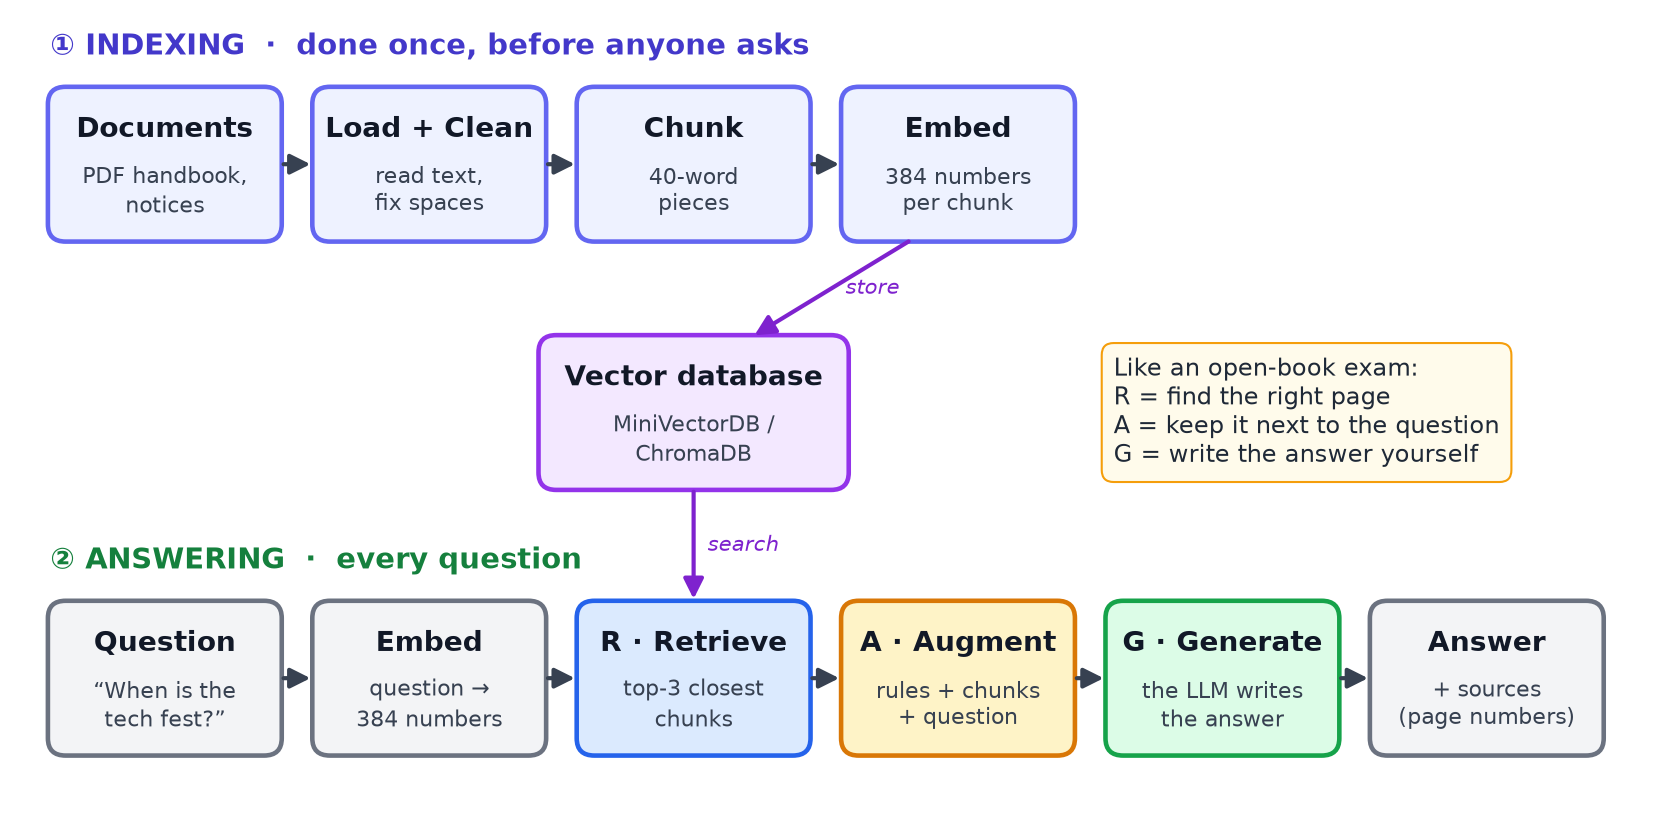

Every RAG system, from a college bot to big products like **Gemini Notebook** and **Perplexity**, has two pipelines:

**🗂️ Pipeline 1: Indexing (done once, before anyone asks)**
Documents → Load → Clean → Chunk → Embed → store in a **vector database**. ✅ We did this in Part 4!

**💬 Pipeline 2: Answering (every time someone asks)**
1. **R · Retrieve:** embed the question → find the top 3 closest chunks.
2. **A · Augment:** paste those chunks + the question into one message (the **prompt**).
3. **G · Generate:** the LLM reads the prompt and writes the answer.

Let's run each step separately.

In [ ]:
# @title 🔎 5.1 · R = Retrieve: find the best chunks for a question
question = "What time does the library close on weekdays?"  # @param {type:"string"}
found = college_db.search(question, top_k=3)
show_results(found)

In [ ]:
PROMPT_TEMPLATE = """Answer the question using ONLY the information below.
If the answer is not in the information, reply exactly: "Sorry, I don't know that from my documents."

Information:
{context}

Question: {question}"""


def build_prompt(question, found):
    """A = Augment: glue the retrieved chunks and the question into one message."""
    context = ""
    for n, chunk in enumerate(found, start=1):
        context += f"[{n}] {chunk['text']}\n\n"
    return PROMPT_TEMPLATE.format(context=context.strip(), question=question)


prompt = build_prompt(question, found)
show_prompt(prompt)

👆 This is **exactly** what the chat model will read: some rules, the retrieved chunks, then the question. No magic!

Now **G = Generate**:

In [ ]:
answer = ask_llm(prompt, system=COLLEGE_SYSTEM)
bot_card(question, answer)

### 🧩 Put it together: the complete RAG pipeline in 3 lines

In [ ]:
def rag_chat(question, db, system=COLLEGE_SYSTEM, top_k=3):
    """Answer a question from the documents in `db`."""
    found = db.search(question, top_k)          # R: retrieve the closest chunks
    prompt = build_prompt(question, found)      # A: augment the question with them
    answer = ask_llm(prompt, system)            # G: generate the answer
    return answer, found


answer, found = rag_chat("Which club should I join if I love coding?", college_db)
bot_card("Which club should I join if I love coding?", answer)

In [ ]:
# @title 💬 5.5 · ✋ Ask Campus Buddy anything about PIT (open book)
question = "How much does a samosa cost?"  # @param {type:"string"}
answer, found = rag_chat(question, college_db)
bot_card(question, answer)
show_results(found)

### ✍️ Practice 5 · Build RAG yourself (5 min)
Replace the three `FILL_ME` with **`question`**, **`found`** or **`prompt`**. (If you forget one, Python says *name 'FILL_ME' is not defined*.) Ask yourself what each step needs:
- **R**etrieve: what do we search the database with?
- **A**ugment: what do we glue to the question?
- **G**enerate: what should the chat model read?

In [ ]:
def my_rag(question):
    found = college_db.search(FILL_ME, top_k=3)          # R: what do we search with?
    prompt = build_prompt(question, FILL_ME)             # A: what do we add to the question?
    answer = ask_llm(FILL_ME, system=COLLEGE_SYSTEM)     # G: what should the chat model read?
    return answer


print(my_rag("Where is the canteen?"))

In [ ]:
# @title ✅ Solution to Practice 5 (open only after you try!) { display-mode: "form" }

def my_rag(question):
    found = college_db.search(question, top_k=3)      # R: search with the question
    prompt = build_prompt(question, found)            # A: add the chunks we found
    answer = ask_llm(prompt, system=COLLEGE_SYSTEM)   # G: the model reads the whole prompt
    return answer


print(my_rag("Where is the canteen?"))

### 🆚 The big test: closed book vs open book
The same questions from Part 1, with and without RAG. ✅ means the answer contains the real fact from the handbook.

In [ ]:
facts = {"What is the name of our college mascot?": "chintu",      # question → a word the right answer must contain
         "What time does the library close on weekdays?": "8:00 pm",
         "What is the most popular dish in the canteen?": "debugger",
         "Who is the director of the college?": "kulkarni",
         "What time do I have to be back in the hostel?": "9:30",
         "When is the tech fest?": "pixel mela"}

rows = []
for question, fact in facts.items():
    if question in closed_book:
        closed = closed_book[question]                      # we already asked this in Part 1
    else:
        closed = ask_llm(question, system=COLLEGE_SYSTEM)    # closed book: no documents
    opened, _ = rag_chat(question, college_db)               # open book: RAG
    rows.append([question, mark(closed, fact in closed.lower()), mark(opened, fact in opened.lower())])
show_table(rows, ["Question", "📕 Closed book (no RAG)", "📖 Open book (RAG)"])

### 🙅 Can it say "I don't know"?
A good assistant admits when the documents don't have the answer. Our prompt told it to. Let's test with questions the handbook does **not** answer.

In [ ]:
for question in ["Who won the IPL in 2026?", "Is there a swimming pool on campus?", "What is the Wi-Fi password?"]:
    answer, _ = rag_chat(question, college_db)
    bot_card(question, answer)

### 🎮 Challenge: Break the bot!
Find a question about PIT that the bot gets **wrong**. When it fails, play detective 🕵️ and **look at the chunks it read**:
- ❓ **Wrong chunks found?** It's a *retrieval* problem. Try a bigger `top_k`, a different chunk size, or rephrase the question.
- ❓ **Right chunk found, wrong answer?** It's a *generation* problem. Small models sometimes misread; bigger models do better.

Try the question we've filled in. Then **slide `top_k` up one step at a time to 6** and watch the answer change. Finally, rephrase it as *"Where do I go to reset my Wi-Fi password?"*

In [ ]:
# @title 🕵️ 5.8 · Break the bot (and find out why it broke)
question = "Where is the IT help desk?"  # @param {type:"string"}
top_k = 3  # @param {type:"slider", min:1, max:6, step:1}
answer, found = rag_chat(question, college_db, top_k=top_k)
bot_card(question, answer)
show_results(found)

### 🕵️ Case file
Why did the bot break? **Write your theory first** (look at the chunks it read!), then open the solution.

<details><summary>👀 Open the case solution</summary>

The handbook mentions the IT Help Desk only <b>inside the Wi-Fi section</b>. The question <i>"Where is the IT help desk?"</i> looks more like other "Room …" chunks (the medical room, the placement cell), so the right chunk ranks <b>6th</b>.
<ul>
<li>With <code>top_k = 3</code> the bot never sees the right chunk, so it <b>invents</b> a room. RAG can still hallucinate when retrieval fails!</li>
<li>With <code>top_k = 4</code> or <code>5</code> it <b>copies the wrong room</b> from a chunk it did see.</li>
<li>With <code>top_k = 6</code>, or a better question, it's correct.</li>
</ul>

</details>

✅ **Checkpoint:** **RAG = Retrieve + Augment + Generate.** Always check the sources: most RAG mistakes are *retrieval* mistakes.

---
## Part 6 · Vector databases: the professional version 🗄️

Our `MiniVectorDB` compares the question with **every** chunk, one by one. Fine for 26 chunks, too slow for **50 million** (think of every product manual on Amazon).

🧠 A **vector database** stores **vectors + text + labels** and finds the nearest vectors **super fast** using clever indexes (like the signboards in a library that take you to the right shelf, instead of checking every book).

| Normal database (SQL) | Vector database |
|---|---|
| Finds **exact** matches: `WHERE name = 'Chintu'` | Finds **nearest meaning**: "something like *camel statue*" |
| Rows and columns | Vectors + text + metadata |
| MySQL, PostgreSQL | **ChromaDB**, FAISS, Pinecone, Qdrant, Weaviate, Milvus, pgvector |

Let's store our handbook in **ChromaDB**, a free, open-source vector database.

In [ ]:
import chromadb

client = chromadb.Client()                                   # a vector database that lives in memory
collection = client.get_or_create_collection(
    name="pit_handbook",
    configuration={"hnsw": {"space": "cosine"}})             # compare vectors with cosine similarity

collection.upsert(                                           # upsert = add, or update if the id already exists
    ids=[f"chunk-{i}" for i in range(len(college_db.texts))],   # every item needs a unique id
    documents=college_db.texts,                                  # the text
    embeddings=[v.tolist() for v in college_db.vectors],         # its embedding (384 numbers)
    metadatas=[{"source": s} for s in college_db.sources],       # labels: file name and page
)
print("🗄️ Chunks stored in ChromaDB:", collection.count())

In [ ]:
# @title 🔎 6.2 · Search ChromaDB (and compare with our MiniVectorDB)
question = "How do I reset my WiFi password?"  # @param {type:"string"}

result = collection.query(query_embeddings=[embedder.encode(question).tolist()], n_results=3)
show_chroma(result)                                      # ChromaDB gives a "distance": similarity = 1 − distance

chroma_best = result["documents"][0][0]                  # [0] = our only question, [0] = its best chunk
our_best = college_db.search(question, top_k=1)[0]["text"]
print("Did our MiniVectorDB pick the same top chunk?", "✅ Yes!" if chroma_best == our_best else "❌ No")

Same answer as the database we built ourselves. Real vector databases add **speed at scale**, **saving to disk**, and **filters**.
For example, search **only page 2**:

In [ ]:
result = collection.query(query_embeddings=[embedder.encode("rules and fines").tolist()], n_results=2,
                          where={"source": "PIT_Student_Handbook.pdf, page 2"})   # metadata filter
for text in result["documents"][0]:
    print("📄", text[:110], "…")

### ✍️ Practice 6 · Ask the vector database (3 min)
Ask ChromaDB your own question. Try **5** results instead of 3, then search **only page 1** or **only page 2**. How do the results change?

In [ ]:
# @title ✍️ Practice 6 · Your own ChromaDB search
my_question = "What are the hostel rules?"  # @param {type:"string"}
how_many = 5  # @param {type:"slider", min:1, max:8, step:1}
only_page = "any page"  # @param ["any page", "PIT_Student_Handbook.pdf, page 1", "PIT_Student_Handbook.pdf, page 2"]

question_vector = embedder.encode(my_question).tolist()
if only_page == "any page":
    result = collection.query(query_embeddings=[question_vector], n_results=how_many)
else:
    result = collection.query(query_embeddings=[question_vector], n_results=how_many, where={"source": only_page})
show_chroma(result)

> 💾 To keep the database after Colab closes, use `chromadb.PersistentClient(path="my_db")` instead of `chromadb.Client()`.

✅ **Checkpoint:** A **vector database** = storage + fast nearest-meaning search + filters. Same idea as ours, industrial strength.

---
## Part 7 · ✋ Your turn: a chatbot about YOUR class (5 minutes)
1. Replace the facts below with **5 fun facts about you and your friends**.
2. Ask questions in the box. Then **swap laptops with your neighbour** and quiz each other's bots!

> 🔒 **Privacy rule (remember Day 7's guardrails):** no phone numbers, addresses, marks or secrets. Anything you put in documents can come out in answers!

In [ ]:
# @title ✋ 7.1 · A chatbot about your class
my_facts = """
Our class CR is Aman.
Priya can solve a Rubik's cube in 40 seconds.
Rahul's favourite cricketer is MS Dhoni.
The best chai near college is at the stall outside the main gate.
Our mini-project is a chatbot for the college library.
"""
question = "Who is our CR?"  # @param {type:"string"}

fact_list = []
for line in my_facts.splitlines():
    if line.strip():                     # skip empty lines
        fact_list.append(line.strip())
my_db = MiniVectorDB()
my_db.add(fact_list, ["my_facts"] * len(fact_list))
answer, found = rag_chat(question, my_db, system="You are a friendly chatbot for our class. Answer in one short sentence.")
bot_card(question, answer, label="🤖 Class Buddy")

---
## Part 8 · 🚀 Launch Campus Buddy: your College/Company RAG chatbot app

We put **everything from today** into a real web app with **Gradio**:
- 📚 Pick a knowledge source: the **college** handbook, the **company** handbook, or **upload your own PDF** (syllabus, notes, a rulebook…).
- 📖 Switch **RAG on/off** to see hallucinations come back.
- 🔍 See **exactly which chunks** the bot read for every answer.

Two cells: **8.1** is the app's *brain* (two small functions that reuse today's code). **8.2** builds the web page with Gradio and launches it (its code is hidden; double-click the cell if you're curious).
Then open the **public link** (`https://….gradio.live`) on your phone and share it with friends! 📱

In [ ]:
# @title 🧠 8.1 · The app's brain: two small functions that reuse today's code
import gradio as gr

SOURCES = {
    "🎓 Pixelpur College (PIT)": ("PIT_Student_Handbook.pdf", COLLEGE_SYSTEM),
    "🏢 CamelCase Company": ("CamelCase_Employee_Handbook.pdf",
                          "You are HR Buddy, the friendly HR help-desk chatbot of CamelCase Technologies. "
                          "Answer in one or two short sentences."),
}
MY_PDF = "📄 My own PDF"
PDF_SYSTEM = "You are a helpful assistant who answers questions about the user's document in one or two short sentences."


def load_knowledge(source, pdf_file, chunk_size):
    """Run the Part 4 pipeline on the chosen source and return its vector database."""
    if source == MY_PDF:
        if not pdf_file:
            return None, "", "⬆️ Upload a PDF first.", []
        path, system = pdf_file, PDF_SYSTEM
    else:
        path, system = SOURCES[source]
    db = pdf_to_db(path, int(chunk_size), int(chunk_size) // 4)
    if not db.texts:
        return None, "", "😕 No text found in this PDF (is it a scanned image?).", []
    return db, system, f"✅ Loaded **{os.path.basename(path)}**: {len(db.texts)} chunks", []


def respond(message, history, db, system, use_rag, top_k):
    """Answer one message, with or without RAG, and show what the bot read."""
    if db is None:
        return "", history, "⚠️ Load a knowledge source first."
    if use_rag:
        answer, found = rag_chat(message, db, system, int(top_k))
        evidence = ""
        for n, chunk in enumerate(found, start=1):
            evidence += f"**#{n}** · similarity {chunk['score']:.2f} · *{chunk['source']}*\n\n> {chunk['text']}\n\n"
    else:
        answer = ask_llm(message, system)
        evidence = "📕 **RAG is OFF:** the bot answered from memory (closed book). It may be making things up!"
    history = history + [{"role": "user", "content": message}, {"role": "assistant", "content": answer}]
    return "", history, evidence


print("✅ The brain is ready. Now run 8.2 to build the web page and launch it.")

In [ ]:
# @title 🎨 8.2 · The app's face: build the web page and launch it { display-mode: "form" }
def upload_pdf(pdf_file, chunk_size):
    """A new PDF was uploaded: switch the source to "My own PDF" and load it straight away."""
    db, system, status, chat = load_knowledge(MY_PDF, pdf_file, chunk_size)
    return MY_PDF, db, system, status, chat


with gr.Blocks(title="Campus Buddy") as demo:
    gr.Markdown("# 🐪 Campus Buddy · a RAG chatbot\nAsk about a college, a company or **your own PDF**. "
                "Built at the SKIT AI workshop, Day 8. No API keys!")
    db_state, system_state = gr.State(), gr.State()
    with gr.Row():
        with gr.Column(scale=1):
            source = gr.Radio(list(SOURCES) + [MY_PDF], value="🎓 Pixelpur College (PIT)", label="1️⃣ Knowledge source")
            pdf_file = gr.File(label="Upload a PDF", file_types=[".pdf"], type="filepath")
            chunk_size = gr.Slider(20, 200, value=40, step=10, label="Chunk size (words)")
            status = gr.Markdown()
            use_rag = gr.Checkbox(value=True, label="📖 Use RAG (open book)")
            top_k = gr.Slider(1, 6, value=3, step=1, label="Chunks to retrieve (top-k)")
        with gr.Column(scale=2):
            chat = gr.Chatbot(height=380, label="💬 Chat")
            message = gr.Textbox(placeholder="Type a question and press Enter…", label="2️⃣ Your question")
            gr.Examples(["What is the name of the college mascot?", "When is the tech fest?",
                         "How many days can I work from home?", "What is the intern stipend?"], inputs=message)
            with gr.Accordion("🔍 What did the bot read? (retrieved chunks)", open=True):
                evidence = gr.Markdown()

    knowledge_inputs = [source, pdf_file, chunk_size]
    knowledge_outputs = [db_state, system_state, status, chat]
    demo.load(load_knowledge, knowledge_inputs, knowledge_outputs)                  # when the page opens
    source.input(load_knowledge, knowledge_inputs, knowledge_outputs)               # when a student clicks a source
    chunk_size.release(load_knowledge, knowledge_inputs, knowledge_outputs)         # when the slider is let go
    pdf_file.upload(upload_pdf, [pdf_file, chunk_size], [source] + knowledge_outputs)   # every upload loads the new PDF
    message.submit(respond, [message, chat, db_state, system_state, use_rag, top_k], [message, chat, evidence])

demo.launch(share=True)

### 🎯 Things to try in the app
1. Ask the **college** questions from today. Open **"What did the bot read?"** and check the sources.
2. Switch to the **company** handbook: *"How many days can I work from home?"*, *"What's the name of the office dog?"*
3. Untick **Use RAG** and ask again. Watch the hallucinations come back! 🤥
4. Upload **your own PDF** (your syllabus, class notes, a club rulebook) and chat with it.
5. Move the **chunk size** and **top-k** sliders. Does the answer get better or worse?

> 🔗 The public link works for about a week while this notebook is running. Don't upload private documents.

---
## Part 9 · 🏆 Quiz time!
Read the questions, choose your answers in the form below, then run the cell.

1. What does **RAG** stand for?
2. What is an **embedding**?
3. Two sentences with the **same meaning** have a cosine similarity close to…
4. Why do we cut documents into **chunks**?
5. What does a **vector database** do?
6. Why did the bot invent the mascot's name in Part 1?
7. Why did keyword search fail on *"space mission to save humanity"*?
8. In RAG, which step writes the final answer?

In [ ]:
# @title 🏆 9.1 · Choose your answers, then run this cell { display-mode: "form" }
Q1 = "choose…"  # @param ["choose…", "A. Random Answer Generator", "B. Retrieval-Augmented Generation", "C. Really Advanced GPT"]
Q2 = "choose…"  # @param ["choose…", "A. A list of numbers that captures meaning", "B. A picture of the text", "C. A password for the model"]
Q3 = "choose…"  # @param ["choose…", "A. 0", "B. -1", "C. 1"]
Q4 = "choose…"  # @param ["choose…", "A. To make the PDF smaller on disk", "B. So search finds small, precise pieces that fit in the LLM's reading limit", "C. Because PDFs have pages"]
Q5 = "choose…"  # @param ["choose…", "A. Stores vectors and quickly finds the nearest ones", "B. Trains the LLM", "C. Converts PDFs to Word"]
Q6 = "choose…"  # @param ["choose…", "A. It had read a wrong handbook", "B. It never saw the handbook, so it predicted likely-sounding words", "C. It was hacked"]
Q7 = "choose…"  # @param ["choose…", "A. It matches exact words, not meaning", "B. The internet was slow", "C. Interstellar is not in the list"]
Q8 = "choose…"  # @param ["choose…", "A. Retrieval", "B. Augmentation", "C. Generation"]

answers = [Q1, Q2, Q3, Q4, Q5, Q6, Q7, Q8]
correct = ["B", "A", "C", "B", "A", "B", "A", "C"]
why = ["Retrieve the right chunks, Augment the prompt with them, Generate the answer.",
       "Embeddings are lists of numbers (384 in our model) that capture meaning.",
       "Same direction = same meaning = cosine similarity close to 1.",
       "Small chunks make search precise and fit in the LLM's context window.",
       "It's a database for meaning: store vectors, find the nearest ones fast.",
       "An LLM predicts likely words. Without the document, it guesses: hallucination.",
       "Keyword search only matches letters: it found 'space' inside PK's 'spaceship'!",
       "Generation: the LLM writes the answer using the retrieved chunks."]

score = sum(a.startswith(c) for a, c in zip(answers, correct))
show_table([[f"Q{n}", "⬜ not answered" if a.startswith("choose") else ("✅" if a.startswith(c) else "❌"), w]
            for n, (a, c, w) in enumerate(zip(answers, correct, why), start=1)], ["Question", "Result", "Why"])
print(f"🏆 Your score: {score} / {len(correct)}")

---
## 🎯 Today in one picture

```
INDEXING (once):     📄 PDF → 🧹 clean → ✂️ chunks → 🔢 embeddings → 🗄️ vector database
ANSWERING (always):  ❓ question → 🔢 embedding → 🔍 top-k chunks → 📨 prompt → 🧠 LLM → 💬 answer + sources
```

| Piece | What we used today (all free) | In big companies |
|---|---|---|
| Embedding model | all-MiniLM-L6-v2 (22M parameters) | Larger embedding models |
| Vector database | MiniVectorDB (ours!) and ChromaDB | Pinecone, Qdrant, Weaviate, pgvector |
| LLM | Qwen2.5-1.5B-Instruct | GPT, Gemini, Claude, Llama |
| App | Gradio | Web and mobile apps |

**RAG in the real world:** college and company help desks, customer-support bots, legal and medical search, **Gemini Notebook** (chat with your PDFs), **Perplexity** (answers with web sources).

### 🔜 Tomorrow, Day 9: AI Agents
Today our bot can **read**. Tomorrow it learns to **act**: use tools like a calculator, a calendar or a search engine, and plan steps on its own.

### 🏠 Homework
Build a bot for **your own PDF** with the homework cells right below 👇

---
## 🏠 Homework · A RAG bot for your own PDF
1. Download a PDF that has real text (your syllabus, a club rulebook, an event notice). Scanned photos won't work.
2. Run the first cell below and upload it.
3. Ask at least 5 questions in the second cell. Post your best question and answer in the class group!

> 🔒 Don't upload private documents (marksheets, ID cards, anything with phone numbers or addresses).

In [ ]:
# @title 🏠 Homework 1 · Upload your PDF
from google.colab import files

uploaded = files.upload()                          # shows a "Choose files" button
pdf_name = list(uploaded.keys())[0]                # the name of the file you picked
my_pdf_db = pdf_to_db(pdf_name)                    # Part 4: Load → Clean → Chunk → Label → Store
print(f"✅ {pdf_name}: {len(my_pdf_db.texts)} chunks")

In [ ]:
# @title 🏠 Homework 2 · Ask your PDF
homework_question = "What are the units of this subject?"  # @param {type:"string"}
answer, found = rag_chat(homework_question, my_pdf_db, system=PDF_SYSTEM)
bot_card(homework_question, answer, label="🤖 My PDF bot")
show_results(found)

---
## 🎁 Bonus for fast finishers

### 🇮🇳 B1 · Search in Hindi!
Our embedding model only learned English. A **multilingual** embedding model maps Hindi and English sentences with the same meaning to the same place, so a Hindi question can find an English story!

In [ ]:
# @title 🇮🇳 B1a · Load a multilingual embedding model (~470 MB, run once)
multilingual = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
multi_movie_vectors = multilingual.encode(list(MOVIES.values()))
print("✅ Multilingual model ready")

In [ ]:
# @title 🇮🇳 B1b · Ask in Hindi (or Hinglish)! { run: "auto" }
hindi_query = "डूबते जहाज़ पर प्रेम कहानी"  # @param {type:"string"}

scores = util.cos_sim(multilingual.encode(hindi_query), multi_movie_vectors)[0]
best = scores.argsort(descending=True)[:3].tolist()
show_ranking(f"🇮🇳 Multilingual model: {hindi_query}", [(movie_titles[i], scores[i].item()) for i in best])
show_ranking(f"🇬🇧 English-only model: {hindi_query}", meaning_search(hindi_query))

Try: `कुश्ती सिखाने वाले पिता और उसकी बेटियाँ`, `अंतरिक्ष में नया ग्रह खोजना`, `dosto ki spain trip`.

### 🌌 B2 · Fly through YOUR embeddings in 3D
Save today's embeddings, then load them into the **TensorFlow Embedding Projector** website.

In [ ]:
# @title 🌌 B2 · Export embeddings for projector.tensorflow.org
texts = college_db.texts + list(MOVIES.values())
labels = college_db.sources + list(MOVIES.keys())
np.savetxt("vectors.tsv", embedder.encode(texts), delimiter="\t")
with open("metadata.tsv", "w") as f:
    f.write("label\ttext\n")
    for label, text in zip(labels, texts):
        f.write(f"{label}\t{text}\n")
print("✅ Saved vectors.tsv and metadata.tsv. Download both from the 📁 Files panel.")
print("🌐 Open https://projector.tensorflow.org → click 'Load' → choose vectors.tsv (step 1) and metadata.tsv (step 2)")